A bank’s credit approval decision is fundamentally a binary classification problem: given an applicant’s characteristics at the time of application, what is the probability that they will default on the loan? The output of this Probability of Default (PD) Model is not a binary approve/decline, rather a score that can be translated into a tiered lending policy:

**Approve automatically**: Applicants with PD below a lower threshold, where expected losses are low enough.

**Manual review**: Individuals in the intermediate band, the model is less certain and human judgment adds significant value.

**Decline**: Applicants with PD above an upper threshold, where expected losses exceed the acceptable level

The goal of this project is to develop a leakage-free and well-evaluated PD model that can predict default risk for new applicants, using a PD score to gauge lending decision. 

# 01 — Exploratory Data Analysis

 This dataset contains 50,000 applicant records with 28 variables, comprising of a mix of demographic and bureau-derived credit history features. Here we will delve into the data itself, and clarify some important questions from the problem statement.


## 0. Imports

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'font.size': 9,
})

DATA_PATH = '../data/case1_credit_approval.csv' 

## 1. Load data

In [11]:
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
df.head(3)

Shape: (50000, 28)


,SK_ID_CURR,TARGET,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,TERM_MONTHS,INTEREST_RATE,DAYS_BIRTH,DAYS_EMPLOYED,EMPLOYMENT_STATUS,...,BUREAU_ACTIVE_LOANS,BUREAU_CLOSED_LOANS,BUREAU_TOTAL_DEBT,BUREAU_TOTAL_CREDIT_LIMIT,BUREAU_UTILIZATION,BUREAU_DPD_30_COUNT,BUREAU_DPD_60_COUNT,BUREAU_DPD_90_COUNT,BUREAU_INQUIRIES_6M,APPLICANT_SCENARIO
0,100000,0,52685.0,56196.0,2665.0,24,0.1275,-15140,-8520,Salaried,...,3.0,3.0,85377.0,135439.0,1.213200,0.0,0.0,0.0,0.0,high_bureau_utilization
1,100001,0,60955.0,87957.0,4403.0,24,0.1827,-15769,-8190,Salaried,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,low_income_high_annuity_burden
2,100002,0,95421.0,67412.0,1892.0,48,0.1545,-18328,-10710,Salaried,...,1.0,1.0,6978.0,99116.0,0.070402,0.0,0.0,0.0,4.0,multiple_recent_inquiries


## 2. Dataset overview

In [12]:
print('dtypes')
print(df.dtypes.to_string())

print('\nNumeric summary') 
df.describe().T.round(2)

dtypes
SK_ID_CURR                                int64
TARGET                                    int64
AMT_INCOME_TOTAL                        float64
AMT_CREDIT                              float64
AMT_ANNUITY                             float64
TERM_MONTHS                               int64
INTEREST_RATE                           float64
DAYS_BIRTH                                int64
DAYS_EMPLOYED                             int64
EMPLOYMENT_STATUS                           str
NAME_CONTRACT_TYPE                          str
HOME_OWNERSHIP                              str
LOAN_PURPOSE                                str
EXT_SOURCE_1                            float64
EXT_SOURCE_2                            float64
EXT_SOURCE_3                            float64
BUREAU_MONTHS_SINCE_LAST_DELINQUENCY    float64
HAS_BUREAU_FILE                           int64
BUREAU_ACTIVE_LOANS                     float64
BUREAU_CLOSED_LOANS                     float64
BUREAU_TOTAL_DEBT                

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,50000.0,124999.50,14433.90,100000.00,112499.75,124999.50,137499.25,149999.00
TARGET,50000.0,0.08,0.27,0.00,0.00,0.00,0.00,1.00
AMT_INCOME_TOTAL,49477.0,158341.02,105303.81,18000.00,87343.00,132827.00,200242.00,1200000.00
AMT_CREDIT,50000.0,560588.50,709762.68,20000.00,157095.25,294362.50,620182.75,3500000.00
AMT_ANNUITY,50000.0,15322.13,19558.51,500.00,4844.00,9390.50,18303.00,327220.00
TERM_MONTHS,50000.0,69.26,70.11,12.00,24.00,48.00,72.00,300.00
INTEREST_RATE,50000.0,0.15,0.04,0.04,0.12,0.14,0.17,0.30
DAYS_BIRTH,50000.0,-14961.66,4147.23,-25913.00,-17895.25,-14969.00,-11701.00,-7665.00
DAYS_EMPLOYED,50000.0,-6586.75,4255.81,-16200.00,-9660.00,-6630.00,-3240.00,0.00
EXT_SOURCE_1,47573.0,0.66,0.19,0.01,0.54,0.68,0.80,0.99


In [13]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f'Categorical columns: {cat_cols}\n')

for col in cat_cols:
    print(df[col].value_counts(dropna=False))
    print(50*'-')

Categorical columns: ['EMPLOYMENT_STATUS', 'NAME_CONTRACT_TYPE', 'HOME_OWNERSHIP', 'LOAN_PURPOSE', 'APPLICANT_SCENARIO']

EMPLOYMENT_STATUS
Salaried         27724
Self-employed    12722
Contract          5880
Pensioner         1986
Unemployed        1688
Name: count, dtype: int64
--------------------------------------------------
NAME_CONTRACT_TYPE
Cash loan      26269
Auto loan       8521
Mortgage        8109
Credit card     7101
Name: count, dtype: int64
--------------------------------------------------
HOME_OWNERSHIP
Rent        21104
Own         12537
Mortgage     8953
Family       7406
Name: count, dtype: int64
--------------------------------------------------
LOAN_PURPOSE
debt_consolidation    15980
working_capital        9080
home_improvement       7362
vehicle                6990
education              4010
other                  3551
medical                3027
Name: count, dtype: int64
--------------------------------------------------
APPLICANT_SCENARIO
prime_stable_low_le

## 3. Class Imbalances

TARGET distribution:
        count  pct (%)
TARGET                
0       45952     91.9
1        4048      8.1

Imbalance ratio (non-default : default) = 11.4 : 1


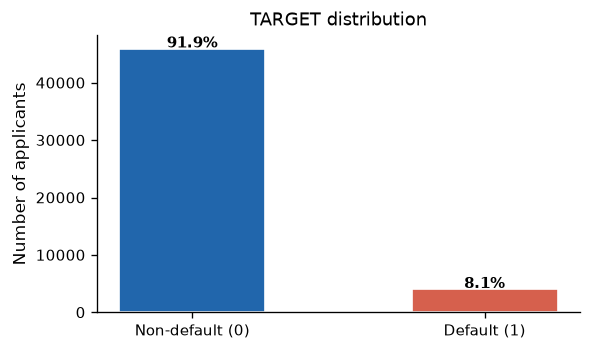

In [14]:
target_counts = df['TARGET'].value_counts()
target_pct    = df['TARGET'].value_counts(normalize=True) * 100

print('TARGET distribution:')
print(pd.DataFrame({'count': target_counts, 'pct (%)': target_pct.round(2)}))
print(f'\nImbalance ratio (non-default : default) = {target_counts[0] / target_counts[1]:.1f} : 1')

fig, ax = plt.subplots(figsize=(5, 3))
colors = ['#2166ac', '#d6604d']
ax.bar(['Non-default (0)', 'Default (1)'], target_counts.values, color=colors, edgecolor='white', width=0.5)
for i, (cnt, pct) in enumerate(zip(target_counts.values, target_pct.values)):
    ax.text(i, cnt + 200, f'{pct:.1f}%', ha='center', fontsize=9, fontweight='bold')
ax.set_ylabel('Number of applicants')
ax.set_title('TARGET distribution')
plt.tight_layout()
plt.show()

**Objective 1: Asess the class imbalance in `TARGET`**

Our target variable takes value 1 for default and 0 for normal repayment. The dataset exhibits significant class imbalance: 8.1% of applicants defaulted, typical of retail credit portfolios, as defaults are rare events by design. The practical implication is that a naive classifier predicting no defaults for every applicant achieves 91.9% accuracy while having zero discriminatory power.  

We will explore appropriate evaluation metrics later in the project, making sure to assess the 2 key methods of judging Credit-Risk models: **Discrimination** (The ability to sort risky from safe) and **Calibration** (whether or not the predicted PDs match reality).

## 4. Missing data analysis

In [15]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct':   df.isnull().mean() * 100
}).sort_values('missing_pct', ascending=False)

missing_nonzero = missing[missing['missing_count'] > 0]
print(f'{len(missing_nonzero)} columns have missing values:\n')
print(missing_nonzero.round(2).to_string())

14 columns have missing values:

                                      missing_count  missing_pct
BUREAU_MONTHS_SINCE_LAST_DELINQUENCY          34144        68.29
BUREAU_DPD_60_COUNT                            8752        17.50
BUREAU_DPD_90_COUNT                            8752        17.50
BUREAU_CLOSED_LOANS                            8752        17.50
BUREAU_TOTAL_DEBT                              8752        17.50
BUREAU_TOTAL_CREDIT_LIMIT                      8752        17.50
BUREAU_UTILIZATION                             8752        17.50
BUREAU_DPD_30_COUNT                            8752        17.50
BUREAU_ACTIVE_LOANS                            8752        17.50
BUREAU_INQUIRIES_6M                            8752        17.50
EXT_SOURCE_2                                   2467         4.93
EXT_SOURCE_3                                   2428         4.86
EXT_SOURCE_1                                   2427         4.85
AMT_INCOME_TOTAL                                523      

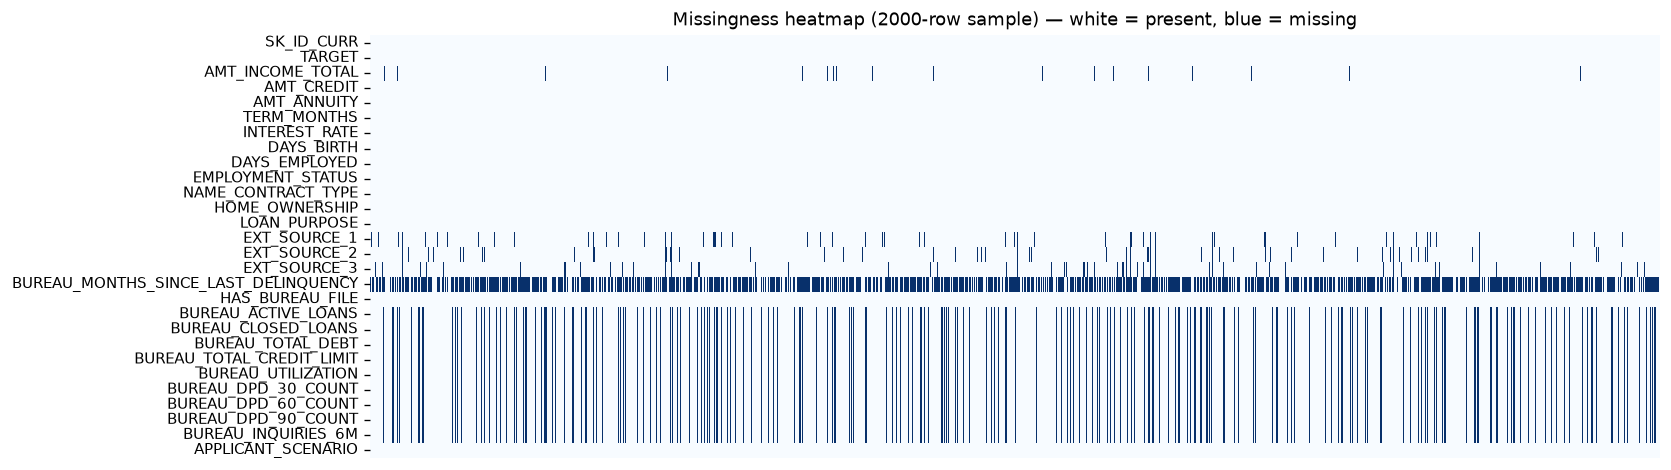

In [16]:
sample = df.sample(2000, random_state=42)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    sample.isnull().T,
    cbar=False,
    yticklabels=True,
    xticklabels=False,
    ax=ax,
    cmap='Blues'
)
ax.set_title('Missingness heatmap (2000-row sample) — white = present, blue = missing')
plt.tight_layout()
plt.show()

In [17]:
bureau_cols = [c for c in df.columns if c.startswith('BUREAU_')]

print('Missing rate for BUREAU_* columns, split by HAS_BUREAU_FILE:')
for col in bureau_cols:
    m0 = df.loc[df['HAS_BUREAU_FILE'] == 0, col].isnull().mean()
    m1 = df.loc[df['HAS_BUREAU_FILE'] == 1, col].isnull().mean()
    print(f'  {col:<40}  no bureau: {m0:.1%}  has bureau: {m1:.1%}')

Missing rate for BUREAU_* columns, split by HAS_BUREAU_FILE:
  BUREAU_MONTHS_SINCE_LAST_DELINQUENCY      no bureau: 100.0%  has bureau: 61.6%
  BUREAU_ACTIVE_LOANS                       no bureau: 100.0%  has bureau: 0.0%
  BUREAU_CLOSED_LOANS                       no bureau: 100.0%  has bureau: 0.0%
  BUREAU_TOTAL_DEBT                         no bureau: 100.0%  has bureau: 0.0%
  BUREAU_TOTAL_CREDIT_LIMIT                 no bureau: 100.0%  has bureau: 0.0%
  BUREAU_UTILIZATION                        no bureau: 100.0%  has bureau: 0.0%
  BUREAU_DPD_30_COUNT                       no bureau: 100.0%  has bureau: 0.0%
  BUREAU_DPD_60_COUNT                       no bureau: 100.0%  has bureau: 0.0%
  BUREAU_DPD_90_COUNT                       no bureau: 100.0%  has bureau: 0.0%
  BUREAU_INQUIRIES_6M                       no bureau: 100.0%  has bureau: 0.0%


**Objective 2: Interpret what missing bureau information may imply**


We see a predictable pattern between the BUREAU_* vars, evident from the heatmap. Missingness is conditional on `HAS_BUREAU_FILE`. Individuals without a bureau file will of course not have any bureau information about them. Interestingly, `BUREAU_MONTHS_SINCE_LAST_DELINQUENCY` has additional missingness even for those who have a bureau file. The explanation is simple, these individuals have just never been delinquent. This implies the missingness is not random, it itself encodes important information, therefore standard imputation would lose valuable information. One solution would be to create a new dummy variable indicating whether an individual had ever been delinquent or not. Solutions are explored in the next notebook.

## 5. Applicant Scenario

Single composite label that summarises multiple vars that already exist separately in the dataset. We already can capture previous delinquency (DPD_30/60/90), utilization, having bureau file (thin-file status), etc. The question is whether APPLICANT_SCENARIO was constructed a priori (relative to loan outcome) or not, in other words if Target was used to construct it. To avoid potential leakage issues / redundancy, we should remove this variable. 

In [18]:
print('APPLICANT_SCENARIO value counts:')
print(df['APPLICANT_SCENARIO'].value_counts())
print()
print('Default rate by APPLICANT_SCENARIO:')
print(
    df.groupby('APPLICANT_SCENARIO')['TARGET']
      .agg(default_rate='mean', count='count')
      .sort_values('default_rate', ascending=False)
      .round(4)
)

APPLICANT_SCENARIO value counts:
APPLICANT_SCENARIO
prime_stable_low_leverage          10937
thin_file_new_to_credit             6148
young_short_employment              4791
good_income_high_credit_amount      4542
high_bureau_utilization             4533
self_employed_income_volatility     4399
low_income_high_annuity_burden      4078
multiple_recent_inquiries           3487
recent_delinquency                  3031
mortgage_like_secured_low_risk      2558
previous_default_history            1031
missing_external_score               465
Name: count, dtype: int64

Default rate by APPLICANT_SCENARIO:
                                 default_rate  count
APPLICANT_SCENARIO                                  
good_income_high_credit_amount         0.3096   4542
previous_default_history               0.2706   1031
recent_delinquency                     0.1752   3031
multiple_recent_inquiries              0.0840   3487
mortgage_like_secured_low_risk         0.0719   2558
missing_external_score